# Lab 3

In [1]:
# Load required libraries
library(readr)
library(dplyr)

# Load dataset
heart_data <- read_csv("/content/heart_disease_uci.csv")

# Display first few rows
head(heart_data)

# Check structure
str(heart_data)

# Check column names
names(heart_data)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Rows: 920 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): sex, dataset, cp, restecg, slope, thal
dbl (8): id, age, trestbps, chol, thalch, oldpeak, ca, num
lgl (2): fbs, exang

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<chr>,<dbl>,<lgl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
1,63,Male,Cleveland,typical angina,145,233,TRUE,lv hypertrophy,150,FALSE,2.3,downsloping,0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160,286,FALSE,lv hypertrophy,108,TRUE,1.5,flat,3,normal,2
3,67,Male,Cleveland,asymptomatic,120,229,FALSE,lv hypertrophy,129,TRUE,2.6,flat,2,reversable defect,1
4,37,Male,Cleveland,non-anginal,130,250,FALSE,normal,187,FALSE,3.5,downsloping,0,normal,0
5,41,Female,Cleveland,atypical angina,130,204,FALSE,lv hypertrophy,172,FALSE,1.4,upsloping,0,normal,0
6,56,Male,Cleveland,atypical angina,120,236,FALSE,normal,178,FALSE,0.8,upsloping,0,normal,0


spc_tbl_ [920 × 16] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ id      : num [1:920] 1 2 3 4 5 6 7 8 9 10 ...
 $ age     : num [1:920] 63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : chr [1:920] "Male" "Male" "Male" "Male" ...
 $ dataset : chr [1:920] "Cleveland" "Cleveland" "Cleveland" "Cleveland" ...
 $ cp      : chr [1:920] "typical angina" "asymptomatic" "asymptomatic" "non-anginal" ...
 $ trestbps: num [1:920] 145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num [1:920] 233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : logi [1:920] TRUE FALSE FALSE FALSE FALSE FALSE ...
 $ restecg : chr [1:920] "lv hypertrophy" "lv hypertrophy" "lv hypertrophy" "normal" ...
 $ thalch  : num [1:920] 150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : logi [1:920] FALSE TRUE TRUE FALSE FALSE FALSE ...
 $ oldpeak : num [1:920] 2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : chr [1:920] "downsloping" "flat" "flat" "downsloping" ...
 $ ca      : num [1:920] 0 3 2 0 0 0 2 0 1

[1] "id"       "age"      "sex"      "dataset"  "cp"       "trestbps"
 [7] "chol"     "fbs"      "restecg"  "thalch"   "exang"    "oldpeak" 
[13] "slope"    "ca"       "thal"     "num"

In [2]:
# Check resting blood pressure
summary(heart_data$trestbps)

# Check for missing values
sum(is.na(heart_data$trestbps))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
    0.0   120.0   130.0   132.1   140.0   200.0      59 

[1] 59

In [3]:
# Make a copy of the original dataset
heart_data_dirty <- heart_data

# Introduce negative BP values
heart_data_dirty$trestbps[1] <- -120
heart_data_dirty$trestbps[2] <- -80

# Introduce missing values
heart_data_dirty$trestbps[3] <- NA
heart_data_dirty$trestbps[4] <- NA

# Introduce extreme BP values
heart_data_dirty$trestbps[5] <- 320
heart_data_dirty$trestbps[6] <- 350

# Check modified values
heart_data_dirty$trestbps[1:10]

[1] -120  -80   NA   NA  320  350  140  120  130  140

In [4]:
clean_bp <- function(bp) {

  if (is.na(bp)) {
    return(NA)

  } else if (bp < 0) {
    return(NA)

  } else if (bp > 250) {
    return(250)

  } else {
    return(bp)
  }
}

In [5]:
clean_bp(-100)
clean_bp(320)
clean_bp(120)
clean_bp(NA)

[1] NA

[1] 250

[1] 120

[1] NA

In [6]:
safe_mean_bp <- function(bp) {

  result <- tryCatch(
    {
      if (length(bp) == 0) {
        stop("BP vector is empty.")
      }

      if (all(is.na(bp))) {
        stop("All BP values are missing.")
      }

      mean(bp, na.rm = TRUE)
    },

    warning = function(w) {
      message("Warning while calculating mean BP: ", w$message)
      NA
    },

    error = function(e) {
      message("Error while calculating mean BP: ", e$message)
      NA
    }
  )

  return(result)
}

# Calculate mean safely
safe_mean_bp(heart_data_dirty$trestbps)

[1] 132.0501

In [7]:
safe_ratio <- function(chol, bp) {

  tryCatch(
    {
      if (is.na(chol) || is.na(bp)) {
        stop("Cholesterol or BP is NA.")
      }

      if (bp == 0) {
        stop("Cannot divide by zero BP.")
      }

      if (bp < 0) {
        stop("BP cannot be negative.")
      }

      ratio <- chol / bp

      return(ratio)
    },

    warning = function(w) {
      message("Warning: ", w$message)
      return(NA)
    },

    error = function(e) {
      message("Invalid ratio: ", e$message)
      return(NA)
    }
  )
}

In [8]:
# Valid case
safe_ratio(200, 120)

# Zero denominator
safe_ratio(200, 0)

# NA denominator
safe_ratio(200, NA)

# Negative denominator
safe_ratio(200, -120)

[1] 1.666667

Invalid ratio: Cannot divide by zero BP.



[1] NA

Invalid ratio: Cholesterol or BP is NA.



[1] NA

Invalid ratio: BP cannot be negative.



[1] NA

In [9]:
# Create a copy
heart_loop <- heart_data_dirty

# Start timer
loop_time <- system.time({

  for (i in 1:nrow(heart_loop)) {
    heart_loop$trestbps[i] <- clean_bp(heart_loop$trestbps[i])
  }

})

# Display execution time
loop_time

   user  system elapsed 
  0.044   0.000   0.043 

In [10]:
head(heart_loop$trestbps, 10)

[1]  NA  NA  NA  NA 250 250 140 120 130 140

In [11]:
heart_vectorized <- heart_data_dirty

vectorized_time <- system.time({

  heart_vectorized$trestbps[
    heart_vectorized$trestbps < 0
  ] <- NA

  heart_vectorized$trestbps[
    heart_vectorized$trestbps > 250
  ] <- 250

})

vectorized_time

   user  system elapsed 
  0.001   0.000   0.000 

In [12]:
cat("For Loop Time:\n")
print(loop_time)

cat("\nVectorized Time:\n")
print(vectorized_time)

For Loop Time:
   user  system elapsed 
  0.044   0.000   0.043 

Vectorized Time:
   user  system elapsed 
  0.001   0.000   0.000 


In [13]:
cat("Loop elapsed time:", loop_time["elapsed"], "seconds\n")

cat("Vectorized elapsed time:",
    vectorized_time["elapsed"],
    "seconds\n")

Loop elapsed time: 0.043 seconds
Vectorized elapsed time: 0 seconds


In [14]:
cleaned_heart_data <- heart_vectorized

In [15]:
missing_bp <- sum(is.na(cleaned_heart_data$trestbps))

cat("Number of missing BP values:", missing_bp, "\n")

Number of missing BP values: 63 


In [16]:
min_bp <- min(cleaned_heart_data$trestbps, na.rm = TRUE)

cat("Minimum BP:", min_bp, "\n")

Minimum BP: 0 


In [17]:
max_bp <- max(cleaned_heart_data$trestbps, na.rm = TRUE)

cat("Maximum BP:", max_bp, "\n")

Maximum BP: 250 


In [18]:
mean_bp <- mean(cleaned_heart_data$trestbps, na.rm = TRUE)

cat("Mean BP:", mean_bp, "\n")

Mean BP: 132.3932 


In [19]:
median_bp <- median(cleaned_heart_data$trestbps, na.rm = TRUE)

cat("Median BP:", median_bp, "\n")

Median BP: 130 


In [20]:
negative_values <- sum(
  cleaned_heart_data$trestbps < 0,
  na.rm = TRUE
)

above_250 <- sum(
  cleaned_heart_data$trestbps > 250,
  na.rm = TRUE
)

cat("Negative BP values remaining:", negative_values, "\n")
cat("BP values greater than 250 remaining:", above_250, "\n")

Negative BP values remaining: 0 
BP values greater than 250 remaining: 0 


In [21]:
cat("----- FINAL BP VALIDATION -----\n")
cat("Missing BP values:", sum(is.na(cleaned_heart_data$trestbps)), "\n")
cat("Minimum BP:", min(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")
cat("Maximum BP:", max(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")
cat("Mean BP:", mean(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")
cat("Median BP:", median(cleaned_heart_data$trestbps, na.rm = TRUE), "\n")
cat("Negative BP values:", sum(cleaned_heart_data$trestbps < 0, na.rm = TRUE), "\n")
cat("BP > 250:", sum(cleaned_heart_data$trestbps > 250, na.rm = TRUE), "\n")

----- FINAL BP VALIDATION -----
Missing BP values: 63 
Minimum BP: 0 
Maximum BP: 250 
Mean BP: 132.3932 
Median BP: 130 
Negative BP values: 0 
BP > 250: 0 


In [22]:
write.csv(
  cleaned_heart_data,
  "cleaned_heart_data.csv",
  row.names = FALSE
)

In [23]:
file.exists("cleaned_heart_data.csv")

[1] TRUE

# Lab 4

In [24]:
# Install packages if required
install.packages("readr")
install.packages("dplyr")
install.packages("naniar")
install.packages("skimr")

# Load libraries
library(readr)
library(dplyr)
library(naniar)
library(skimr)

# Load Adult dataset
adult_data <- read_csv("/content/adult.csv")

# View first few rows
head(adult_data)

# Check structure
str(adult_data)

# Check column names
names(adult_data)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in install.packages("readr"):
“installation of package ‘readr’ had non-zero exit status”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete


Rows: 48842 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): workclass, education, marital-status, occupation, relationship, rac...
dbl (6): age, fnlwgt, educational-num, capital-gain, capital-loss, hours-per...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the 

age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


spc_tbl_ [48,842 × 15] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ age            : num [1:48842] 25 38 28 44 18 34 29 63 24 55 ...
 $ workclass      : chr [1:48842] "Private" "Private" "Local-gov" "Private" ...
 $ fnlwgt         : num [1:48842] 226802 89814 336951 160323 103497 ...
 $ education      : chr [1:48842] "11th" "HS-grad" "Assoc-acdm" "Some-college" ...
 $ educational-num: num [1:48842] 7 9 12 10 10 6 9 15 10 4 ...
 $ marital-status : chr [1:48842] "Never-married" "Married-civ-spouse" "Married-civ-spouse" "Married-civ-spouse" ...
 $ occupation     : chr [1:48842] "Machine-op-inspct" "Farming-fishing" "Protective-serv" "Machine-op-inspct" ...
 $ relationship   : chr [1:48842] "Own-child" "Husband" "Husband" "Husband" ...
 $ race           : chr [1:48842] "Black" "White" "White" "Black" ...
 $ gender         : chr [1:48842] "Male" "Male" "Male" "Male" ...
 $ capital-gain   : num [1:48842] 0 0 0 7688 0 ...
 $ capital-loss   : num [1:48842] 0 0 0 0 0 0 0 0 0 0 ...
 $ hours-per-we

[1] "age"             "workclass"       "fnlwgt"          "education"      
 [5] "educational-num" "marital-status"  "occupation"      "relationship"   
 [9] "race"            "gender"          "capital-gain"    "capital-loss"   
[13] "hours-per-week"  "native-country"  "income"

In [25]:
# Summary of dataset
summary(adult_data)

# Count existing missing values
sum(is.na(adult_data))

# Missing values column-wise
colSums(is.na(adult_data))

      age            workclass         fnlwgt            education    
 Min.   :17.00   Length   :48842   Min.   :  12285   Length   :48842  
 1st Qu.:28.00   N.unique :    9   1st Qu.: 117550   N.unique :   16  
 Median :37.00   N.blank  :    0   Median : 178144   N.blank  :    0  
 Mean   :38.64   Min.nchar:    1   Mean   : 189664   Min.nchar:    3  
 3rd Qu.:48.00   Max.nchar:   16   3rd Qu.: 237642   Max.nchar:   12  
 Max.   :90.00                     Max.   :1490400                    
 educational-num   marital-status      occupation       relationship  
 Min.   : 1.00   Length   :48842   Length   :48842   Length   :48842  
 1st Qu.: 9.00   N.unique :    7   N.unique :   15   N.unique :    6  
 Median :10.00   N.blank  :    0   N.blank  :    0   N.blank  :    0  
 Mean   :10.08   Min.nchar:    7   Min.nchar:    1   Min.nchar:    4  
 3rd Qu.:12.00   Max.nchar:   21   Max.nchar:   17   Max.nchar:   14  
 Max.   :16.00                                                        
      

[1] 0

age       workclass          fnlwgt       education educational-num 
              0               0               0               0               0 
 marital-status      occupation    relationship            race          gender 
              0               0               0               0               0 
   capital-gain    capital-loss  hours-per-week  native-country          income 
              0               0               0               0               0

In [26]:
adult_dirty <- adult_data

In [27]:
adult_dirty$age[1] <- NA

In [28]:
adult_dirty$age[2] <- NaN

In [29]:
adult_dirty$workclass[3] <- ""

In [30]:
adult_dirty$occupation[4] <- ""

In [31]:
adult_dirty$age[5] <- 999

In [32]:
adult_dirty[1:5, c("age", "workclass", "occupation")]

age,workclass,occupation
<dbl>,<chr>,<chr>
NA,Private,Machine-op-inspct
NaN,Private,Farming-fishing
28,,Protective-serv
44,Private,
999,?,?


In [33]:
x <- NA

is.na(x)

[1] TRUE

In [34]:
x <- NaN

is.nan(x)

[1] TRUE

In [35]:
is.na(NaN)

[1] TRUE

In [36]:
x <- NULL

is.null(x)

[1] TRUE

In [80]:
test_df <- data.frame(
  name = c("A", "B"),
  age = c(20, 21)
)

test_df$missing_column <- NULL

is.null(test_df$missing_column)

[1] TRUE

In [37]:
x <- NULL

length(x)

[1] 0

In [38]:
x <- ""

x == ""

[1] TRUE

In [39]:
sum(is.na(adult_dirty))

[1] 2

In [40]:
sum(is.nan(adult_dirty$age))

[1] 1

In [41]:
sum(adult_dirty$workclass == "", na.rm = TRUE)

[1] 1

In [42]:
sum(adult_dirty$occupation == "", na.rm = TRUE)

[1] 1

In [43]:
sum(adult_dirty$age == 999, na.rm = TRUE)

[1] 1

In [44]:
miss_var_summary(adult_dirty)

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,2,0.004[4m0[24m[4m9[24m
workclass,0,0
fnlwgt,0,0
education,0,0
educational-num,0,0
marital-status,0,0
occupation,0,0
relationship,0,0
race,0,0


In [45]:
missing_summary_before <- miss_var_summary(adult_dirty)

missing_summary_before

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,2,0.004[4m0[24m[4m9[24m
workclass,0,0
fnlwgt,0,0
education,0,0
educational-num,0,0
marital-status,0,0
occupation,0,0
relationship,0,0
race,0,0


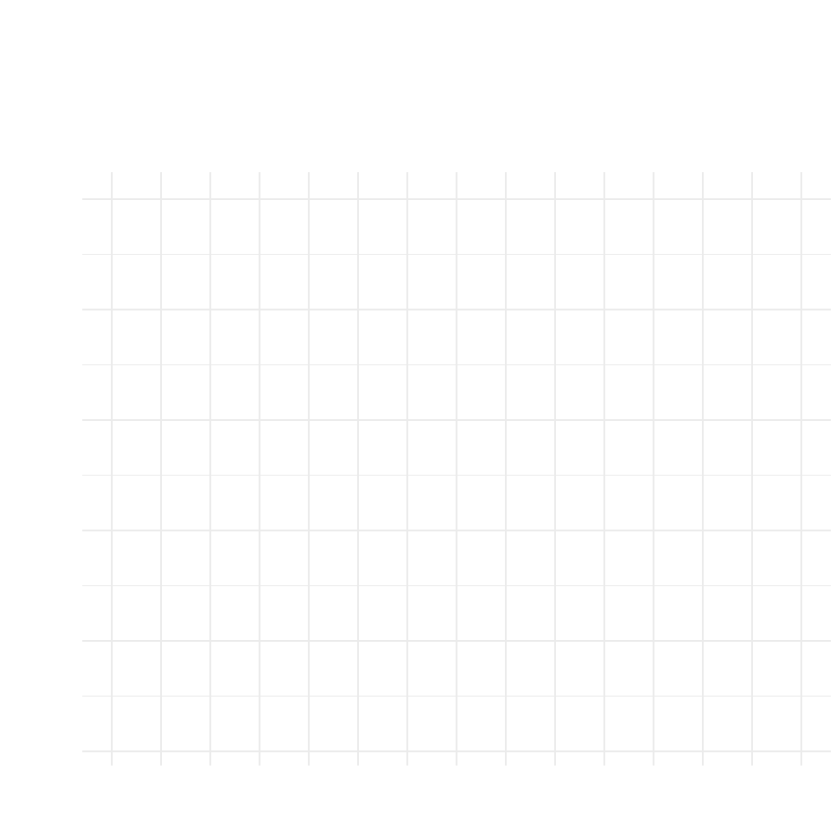

In [46]:
vis_miss(adult_dirty)

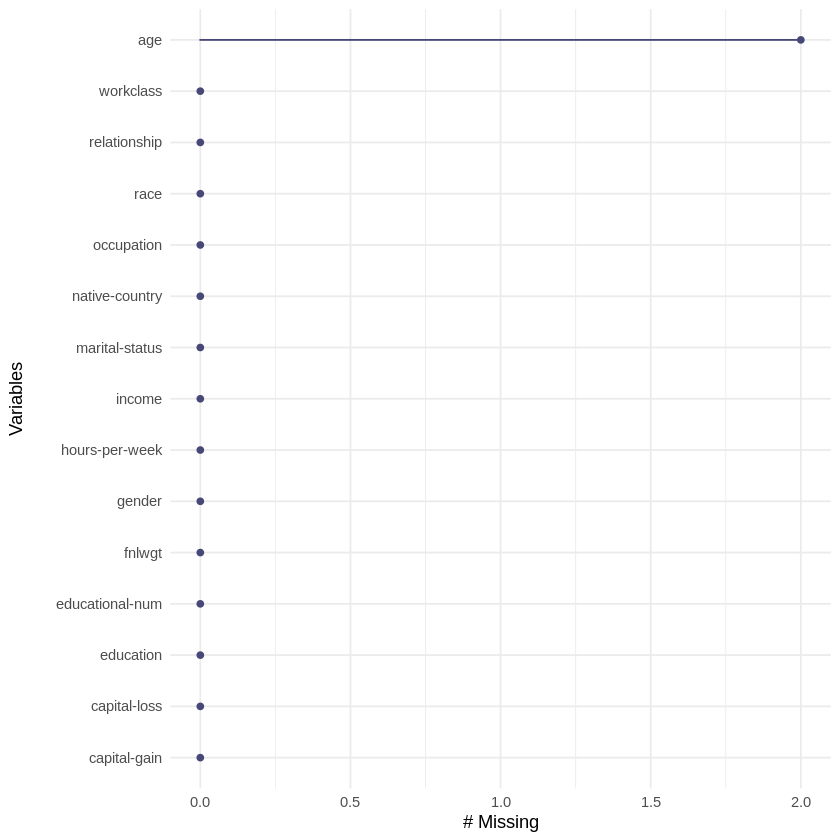

In [47]:
gg_miss_var(adult_dirty)

In [48]:
adult_clean <- adult_dirty

adult_clean$age[
  adult_clean$age == 999
] <- NA

In [49]:
sum(adult_clean$age == 999, na.rm = TRUE)

[1] 0

In [50]:
adult_clean$workclass[
  adult_clean$workclass == ""
] <- "Unknown"

In [51]:
adult_clean$occupation[
  adult_clean$occupation == ""
] <- "Unknown"

In [52]:
sum(adult_clean$workclass == "", na.rm = TRUE)

sum(adult_clean$occupation == "", na.rm = TRUE)

[1] 0

[1] 0

In [53]:
sum(is.nan(adult_clean$age))

[1] 1

In [54]:
adult_clean$age[
  is.nan(adult_clean$age)
] <- NA

NaN values in the numeric age variable are converted to NA and subsequently handled using median imputation because age is a recoverable numeric attribute.

In [55]:
sum(is.nan(adult_clean$age))

[1] 0

In [56]:
median_impute <- function(x) {

  # Check whether input is numeric
  if (!is.numeric(x)) {
    stop("Input must be a numeric vector.")
  }

  # Calculate median of valid observations
  med <- median(x, na.rm = TRUE)

  # Replace NA/NaN with median
  x[is.na(x)] <- med

  return(x)
}

In [57]:
test_vector <- c(20, 25, NA, 30, NaN, 35)

median_impute(test_vector)

[1] 20.0 25.0 27.5 30.0 27.5 35.0

In [58]:
adult_clean$age <- median_impute(adult_clean$age)

In [62]:
adult_clean$fnlwgt <- median_impute(adult_clean$fnlwgt)

adult_clean$`educational-num` <- median_impute(adult_clean$`educational-num`)

adult_clean$`hours-per-week` <- median_impute(adult_clean$`hours-per-week`)

In [63]:
names(adult_clean)[sapply(adult_clean, is.numeric)]

[1] "age"             "fnlwgt"          "educational-num" "capital-gain"   
[5] "capital-loss"    "hours-per-week"

In [64]:
colSums(is.na(adult_clean))

age       workclass          fnlwgt       education educational-num 
              0               0               0               0               0 
 marital-status      occupation    relationship            race          gender 
              0               0               0               0               0 
   capital-gain    capital-loss  hours-per-week  native-country          income 
              0               0               0               0               0

In [65]:
sum(is.na(adult_clean))

[1] 0

In [66]:
missing_before <- sum(is.na(adult_dirty))

missing_after <- sum(is.na(adult_clean))

cat("Missing values before cleaning:", missing_before, "\n")
cat("Missing values after cleaning:", missing_after, "\n")

Missing values before cleaning: 2 
Missing values after cleaning: 0 


In [67]:
total_values_before <- nrow(adult_dirty) * ncol(adult_dirty)

total_values_after <- nrow(adult_clean) * ncol(adult_clean)

percentage_before <- (missing_before / total_values_before) * 100

percentage_after <- (missing_after / total_values_after) * 100

cat("Missing percentage before:", percentage_before, "%\n")
cat("Missing percentage after:", percentage_after, "%\n")

Missing percentage before: 0.0002729891 %
Missing percentage after: 0 %


In [68]:
cat("----- BEFORE CLEANING -----\n")

miss_var_summary(adult_dirty)

cat("\n----- AFTER CLEANING -----\n")

miss_var_summary(adult_clean)

----- BEFORE CLEANING -----


variable,n_miss,pct_miss
<chr>,<int>,<num>
age,2,0.004[4m0[24m[4m9[24m
workclass,0,0
fnlwgt,0,0
education,0,0
educational-num,0,0
marital-status,0,0
occupation,0,0
relationship,0,0
race,0,0



----- AFTER CLEANING -----


variable,n_miss,pct_miss
<chr>,<int>,<num>
age,0,0
workclass,0,0
fnlwgt,0,0
education,0,0
educational-num,0,0
marital-status,0,0
occupation,0,0
relationship,0,0
race,0,0


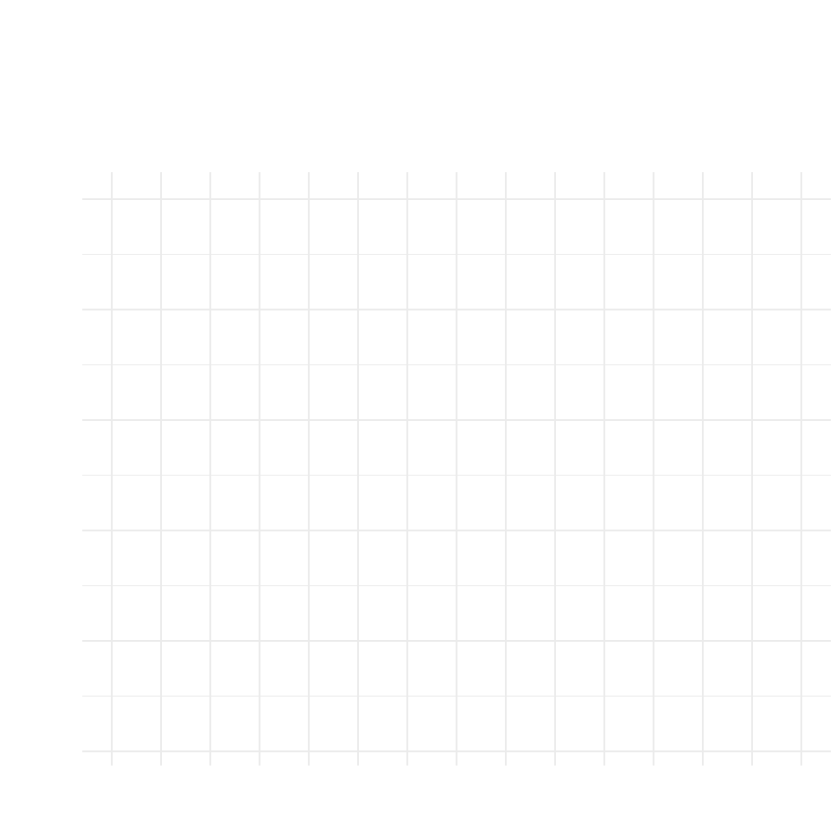

In [69]:
vis_miss(adult_clean)

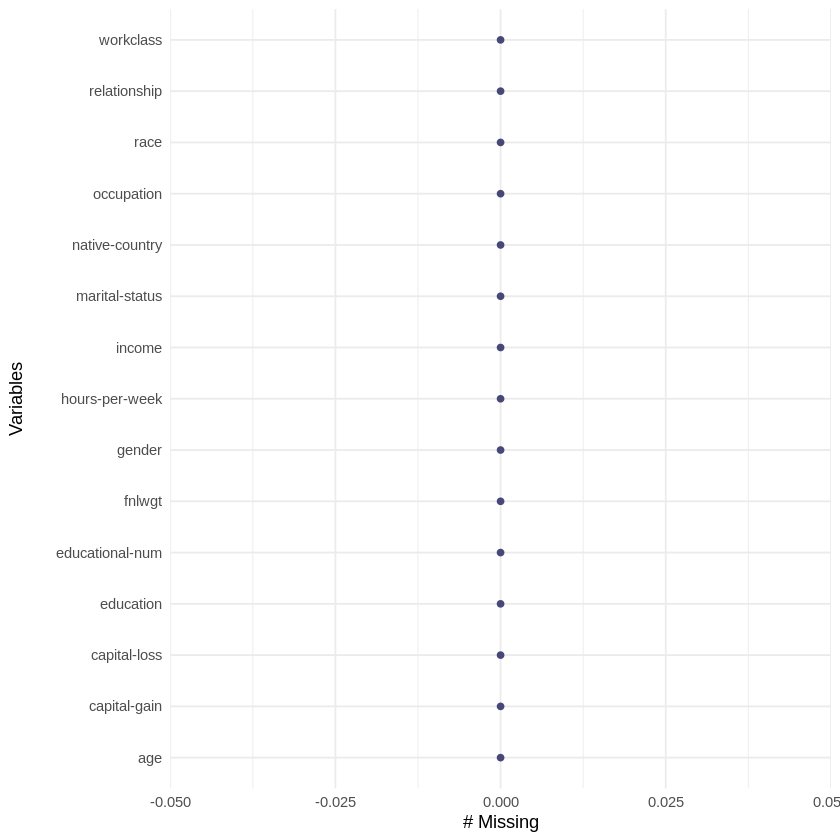

In [70]:
gg_miss_var(adult_clean)

In [71]:
sum(!complete.cases(adult_clean))

[1] 0

In [72]:
sum(complete.cases(adult_clean))

[1] 48842

In [73]:
adult_complete <- adult_clean[complete.cases(adult_clean), ]

In [74]:
sum(adult_clean$age == 999, na.rm = TRUE)

[1] 0

In [75]:
sum(adult_clean$workclass == "", na.rm = TRUE)

sum(adult_clean$occupation == "", na.rm = TRUE)

[1] 0

[1] 0

In [76]:
skim(adult_clean)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,1,1,16,0,10,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,1,3,12,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital-status,0,1,7,21,0,7,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,1,1,17,0,16,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,1,4,14,0,6,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,1,5,18,0,5,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,gender,0,1,4,6,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native-country,0,1,1,26,0,42,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,1,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA


In [77]:
cat("========== FINAL VALIDATION ==========\n")

cat("Total rows:", nrow(adult_clean), "\n")

cat("Total columns:", ncol(adult_clean), "\n")

cat("Total missing values:", sum(is.na(adult_clean)), "\n")

cat("NaN values in age:", sum(is.nan(adult_clean$age)), "\n")

cat("Age = 999 values:",
    sum(adult_clean$age == 999, na.rm = TRUE), "\n")

cat("Blank workclass values:",
    sum(adult_clean$workclass == "", na.rm = TRUE), "\n")

cat("Blank occupation values:",
    sum(adult_clean$occupation == "", na.rm = TRUE), "\n")

========== FINAL VALIDATION ==========
Total rows: 48842 
Total columns: 15 
Total missing values: 0 
NaN values in age: 0 
Age = 999 values: 0 
Blank workclass values: 0 
Blank occupation values: 0 


In [78]:
write.csv(
  adult_clean,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

In [79]:
file.exists("cleaned_adult_data.csv")

[1] TRUE